Exact probability without replacement = 0.7779510789
Exact probability with replacement    = 0.7408447266

N        | MC without repl. | error without | MC with repl.    | error with
------------------------------------------------------------------------------
     100 |      0.8500000000 |  0.0720489211 |      0.7400000000 | 0.0008447266
    1000 |      0.7640000000 |  0.0139510789 |      0.7550000000 | 0.0141552734
   10000 |      0.7857000000 |  0.0077489211 |      0.7407000000 | 0.0001447266
  100000 |      0.7785100000 |  0.0005589211 |      0.7398100000 | 0.0010347266


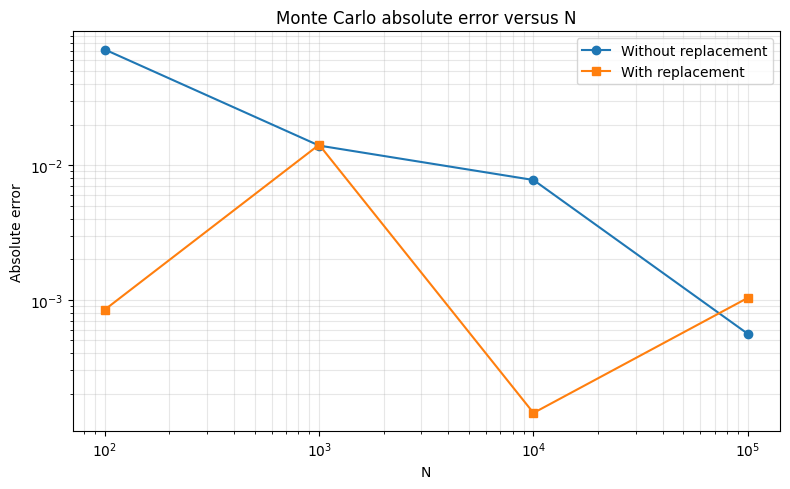

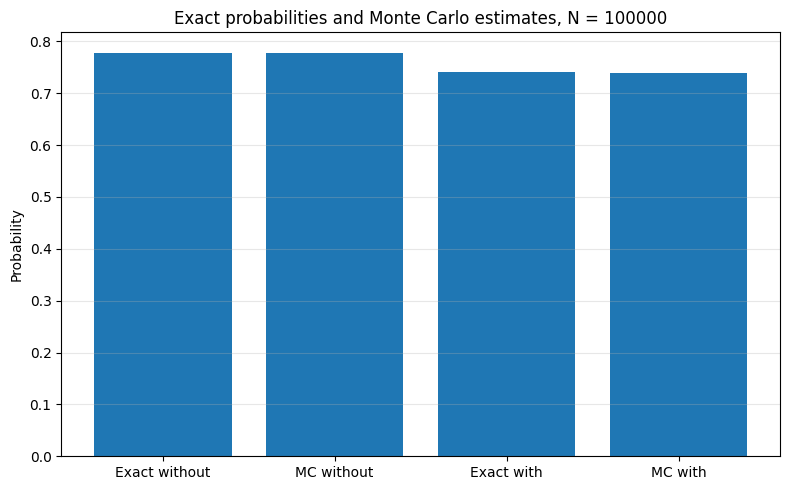

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


# Define the random seed used to make the simulations reproducible.
SEED = 1

# Define the Monte Carlo sample sizes used to study convergence.
N_VALUES = np.array([10**2, 10**3, 10**4, 10**5], dtype=int)

# Define the number of card draws in each experiment.
N_DRAWS = 7


def exact_probability_without_replacement() -> float:
    """Compute the exact probability without replacement.

    The event is:
        at least one card of type B and at least one card of type D
        in 7 draws from a deck with 12 cards of each type A, B, C, D.

    Using inclusion-exclusion:
        P(E) = 1 - P(no B) - P(no D) + P(no B and no D)

    Returns:
        Exact probability without replacement.
    """
    # Compute the total number of ways to choose 7 cards from 48 cards.
    total = math.comb(48, 7)

    # Compute the number of ways to choose 7 cards with no B cards.
    no_b = math.comb(36, 7)

    # Compute the number of ways to choose 7 cards with no D cards.
    no_d = math.comb(36, 7)

    # Compute the number of ways to choose 7 cards using only A and C.
    no_b_no_d = math.comb(24, 7)

    # Apply the inclusion-exclusion formula.
    probability = 1.0 - no_b / total - no_d / total + no_b_no_d / total

    # Return the exact probability.
    return probability


def exact_probability_with_replacement() -> float:
    """Compute the exact probability with replacement.

    In each draw:
        P(B) = 1/4
        P(D) = 1/4

    Using inclusion-exclusion:
        P(E) = 1 - P(no B) - P(no D) + P(no B and no D)

    Returns:
        Exact probability with replacement.
    """
    # Compute the probability that no B appears in 7 independent draws.
    no_b = (3.0 / 4.0) ** N_DRAWS

    # Compute the probability that no D appears in 7 independent draws.
    no_d = (3.0 / 4.0) ** N_DRAWS

    # Compute the probability that only A or C appears in all 7 draws.
    no_b_no_d = (1.0 / 2.0) ** N_DRAWS

    # Apply the inclusion-exclusion formula.
    probability = 1.0 - no_b - no_d + no_b_no_d

    # Return the exact probability.
    return probability


def build_deck() -> np.ndarray:
    """Create the deck representation for the case without replacement.

    We encode the card types as:
        0 -> A
        1 -> B
        2 -> C
        3 -> D

    Returns:
        NumPy array representing the 48-card deck.
    """
    # Create 12 copies of each card type and concatenate them into one deck.
    deck = np.array([0] * 12 + [1] * 12 + [2] * 12 + [3] * 12, dtype=int)

    # Return the deck array.
    return deck


def event_has_b_and_d(sample: np.ndarray) -> bool:
    """Check whether a sample contains at least one B and at least one D.

    Args:
        sample: Array containing the drawn card types.

    Returns:
        True if the sample contains at least one B and at least one D,
        False otherwise.
    """
    # Check if the sample contains at least one card of type B.
    has_b = np.any(sample == 1)

    # Check if the sample contains at least one card of type D.
    has_d = np.any(sample == 3)

    # The event occurs only if both conditions are true.
    return bool(has_b and has_d)


def monte_carlo_without_replacement(n_trials: int, seed: int) -> float:
    """Estimate the probability without replacement using Monte Carlo.

    Args:
        n_trials: Number of Monte Carlo experiments.
        seed: Seed used by the random number generator.

    Returns:
        Monte Carlo estimate of the probability without replacement.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Build the fixed 48-card deck used in every experiment.
    deck = build_deck()

    # Initialize the counter of successful experiments.
    success_count = 0

    # Repeat the experiment n_trials times.
    for _ in range(n_trials):
        # Draw 7 cards from the deck without replacement.
        sample = rng.choice(deck, size=N_DRAWS, replace=False)

        # Check whether the event of interest happened in this experiment.
        if event_has_b_and_d(sample):
            # Increase the number of successful experiments.
            success_count += 1

    # Return the relative frequency of success.
    return success_count / n_trials


def monte_carlo_with_replacement(n_trials: int, seed: int) -> float:
    """Estimate the probability with replacement using Monte Carlo.

    Args:
        n_trials: Number of Monte Carlo experiments.
        seed: Seed used by the random number generator.

    Returns:
        Monte Carlo estimate of the probability with replacement.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Initialize the counter of successful experiments.
    success_count = 0

    # Repeat the experiment n_trials times.
    for _ in range(n_trials):
        # Draw 7 card types independently with replacement.
        sample = rng.integers(0, 4, size=N_DRAWS)

        # Check whether the event of interest happened in this experiment.
        if event_has_b_and_d(sample):
            # Increase the number of successful experiments.
            success_count += 1

    # Return the relative frequency of success.
    return success_count / n_trials


def main() -> None:
    """Run the analytical calculations and Monte Carlo simulations."""
    # Compute the exact probability for the case without replacement.
    exact_without = exact_probability_without_replacement()

    # Compute the exact probability for the case with replacement.
    exact_with = exact_probability_with_replacement()

    # Print the exact analytical results.
    print(f"Exact probability without replacement = {exact_without:.10f}")
    print(f"Exact probability with replacement    = {exact_with:.10f}")
    print()

    # Create empty lists to store the estimates without replacement.
    estimates_without = []

    # Create empty lists to store the estimates with replacement.
    estimates_with = []

    # Create empty lists to store the absolute errors without replacement.
    errors_without = []

    # Create empty lists to store the absolute errors with replacement.
    errors_with = []

    # Print a table header for the Monte Carlo results.
    print("N        | MC without repl. | error without | MC with repl.    | error with")
    print("-" * 78)

    # Loop over all requested Monte Carlo sample sizes.
    for n in N_VALUES:
        # Estimate the probability without replacement for the current N.
        estimate_without = monte_carlo_without_replacement(
            n_trials=n,
            seed=SEED + n,
        )

        # Estimate the probability with replacement for the current N.
        estimate_with = monte_carlo_with_replacement(
            n_trials=n,
            seed=SEED + 10 * n,
        )

        # Compute the absolute error for the case without replacement.
        error_without = abs(estimate_without - exact_without)

        # Compute the absolute error for the case with replacement.
        error_with = abs(estimate_with - exact_with)

        # Store the estimate without replacement.
        estimates_without.append(estimate_without)

        # Store the estimate with replacement.
        estimates_with.append(estimate_with)

        # Store the absolute error without replacement.
        errors_without.append(error_without)

        # Store the absolute error with replacement.
        errors_with.append(error_with)

        # Print the results for the current Monte Carlo size.
        print(
            f"{n:8d} | {estimate_without:17.10f} | {error_without:13.10f} | "
            f"{estimate_with:17.10f} | {error_with:10.10f}"
        )

    # Convert the lists of estimates into NumPy arrays.
    estimates_without = np.array(estimates_without)

    # Convert the lists of estimates into NumPy arrays.
    estimates_with = np.array(estimates_with)

    # Convert the lists of errors into NumPy arrays.
    errors_without = np.array(errors_without)

    # Convert the lists of errors into NumPy arrays.
    errors_with = np.array(errors_with)

    # Create a figure to compare the absolute errors.
    plt.figure(figsize=(8, 5))

    # Plot the absolute error without replacement on log-log axes.
    plt.loglog(
        N_VALUES,
        errors_without,
        marker="o",
        label="Without replacement",
    )

    # Plot the absolute error with replacement on log-log axes.
    plt.loglog(
        N_VALUES,
        errors_with,
        marker="s",
        label="With replacement",
    )

    # Label the horizontal axis.
    plt.xlabel("N")

    # Label the vertical axis.
    plt.ylabel("Absolute error")

    # Add a title to the figure.
    plt.title("Monte Carlo absolute error versus N")

    # Add a grid for readability.
    plt.grid(True, which="both", alpha=0.3)

    # Add the legend.
    plt.legend()

    # Adjust the layout.
    plt.tight_layout()

    # Create a figure to compare exact values and largest-N estimates.
    plt.figure(figsize=(8, 5))

    # Create labels for the bar plot.
    labels = [
        "Exact without",
        "MC without",
        "Exact with",
        "MC with",
    ]

    # Create the values used in the bar plot.
    values = [
        exact_without,
        estimates_without[-1],
        exact_with,
        estimates_with[-1],
    ]

    # Plot the comparison bars.
    plt.bar(labels, values)

    # Label the vertical axis.
    plt.ylabel("Probability")

    # Add a title to the figure.
    plt.title(f"Exact probabilities and Monte Carlo estimates, N = {N_VALUES[-1]}")

    # Add a grid on the y-axis.
    plt.grid(True, axis="y", alpha=0.3)

    # Adjust the layout.
    plt.tight_layout()

    # Show all figures.
    plt.show()


main()